In [1]:
# （必須）モジュールのインポート
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 表示設定
np.set_printoptions(suppress=True, precision=3)
pd.set_option('display.precision', 3)    # 小数点以下の表示桁
pd.set_option('display.max_rows', 10)   # 表示する行数の上限
pd.set_option('display.max_columns', 20)  # 表示する列数の上限
%precision 3

'%.3f'

# イベントデータの解析

## イベントデータ

### Pappalardo-Wyscoutデータセット

Pappalardo-Wyscoutデータセットはサッカーのイベントデータをまとめたオープンデータセットである．
Wyscout社によって収集されたデータをL. Pappalardoらが編集し[CC BY 4.0ライセンス](https://creativecommons.org/licenses/by/4.0/deed.ja)の下で提供されている．
現在一般公開されているサッカーのイベントデータセットの中では最大級である．
データセットの詳細については付録を参照のこと：{ref}`pappalardo`

### 本講義で用いる加工済みデータ

Pappalardo-Wyscoutデータセットはjson形式で提供されており，このままではデータ分析がしづらい．
そこで，json形式のデータを加工・整形したデータをcsv形式で提供する．
以下では，加工済みデータの一部を使ったデータ解析の例を示す．

## リーグ成績と順位表

リーグの最終的な順位は勝ち点によって決まる．
サッカーでは，試合に勝利すると3点，引き分けだと1点，敗北だと0点の勝ち点が与えられる．
試合別の得点データを用いれば，チームごとに勝ち点を計算し，順位表を作成することができる．
以下では，イングランド・プレミアリーグの最終成績と順位表を作成してみよう．
なお，2017年度イングランド・プレミアリーグの最終成績と順位表は以下で確認できる：
- [https://ja.wikipedia.org/wiki/プレミアリーグ2017-2018](https://ja.wikipedia.org/wiki/%E3%83%97%E3%83%AC%E3%83%9F%E3%82%A2%E3%83%AA%E3%83%BC%E3%82%B02017-2018)
- [Premier League Table, Form Guide & Season Archives](https://www.premierleague.com/tables?co=1&se=79&mw=-1&ha=-1)

### データの読み込み

まずは試合情報のデータ（[game.csv](https://tnarizuka.github.io/sports_data_programming/chap_6/game.csv)）をダウンロードしてカレントディレクトリに移動し，`df_game`という名前のDataFrameに読み込む．

In [3]:
# 試合情報のデータを読み込む
df_game = pd.read_csv('./game.csv', header=0)
df_game.head(5)

,game_id,league,section,date,venue,away,away_id,home,home_id,away_score,home_score
0,2499719,England,1,2017-08-11,Emirates_Stadium,Leicester_City,1631,Arsenal,1609,3,4
1,2499723,England,1,2017-08-12,Goodison_Park,Stoke_City,1639,Everton,1623,0,1
2,2499724,England,1,2017-08-13,Old_Trafford,West_Ham_United,1633,Manchester_United,1611,0,4
3,2499722,England,1,2017-08-12,Selhurst_Park,Huddersfield_Town,1673,Crystal_Palace,1628,3,0
4,2499725,England,1,2017-08-13,St_James'_Park,Tottenham_Hotspur,1624,Newcastle_United,1613,2,0


このデータの各行には2017年度ヨーロッパリーグの全試合の情報が記録されている．
各列の意味は下表の通りである．
このうち，`away_score`列と`home_score`列がアウェイチームとホームチームの得点である．
例えば，第0行はアーセナル（ホーム）対レイチェスターシティ（アウェイ）の試合情報を表し，アーセナルが4-3で勝利したことが分かる．

| 各列の変数 | 内容 |
| ---- | ---- |
| game_id | 試合ID |
| league | リーグ名 |
| section | 節（全38節）|
| date | 日付 |
| venue | 試合地 |
| away | アウェイチーム名 |
| away_id | アウェイチームID |
| home | ホームチーム名 |
| home_id | ホームチームID |
| away_score | アウェイチームのスコア |
| home_score |  ホームチームのスコア |

次にチーム情報のデータ（[team.csv](https://tnarizuka.github.io/sports_data_programming/chap_6/team.csv)）をダウンロードしてカレントディレクトリに移動し，`df_team`という名前のDataFrameに読み込む．

In [4]:
# チーム情報のデータを読み込む
df_team = pd.read_csv('./team.csv', header=0)
df_team.head()

,name,team_id,city,country,league
0,Arsenal,1609,London,England,England
1,Chelsea,1610,London,England,England
2,Manchester_United,1611,Manchester,England,England
3,Liverpool,1612,Liverpool,England,England
4,Newcastle_United,1613,Newcastle_upon_Tyne,England,England


このデータの各行には2017年度ヨーロッパリーグの全クラブチームの情報が記録されている．
各列の意味は下表の通りである．
例えば，第0行はイングランド・プレミアリーグに所属するアーセナルのチーム情報を表している．

| 各列の変数 | 内容 |
| ---- | ---- |
| name | チームの俗称 |
| team_id | チームID|
| city | チームの所在都市 |
| country | チームの所在国 |
| league | チームの所属リーグ | 

以下では，イングランド・プレミアリーグのデータを解析対象とする．
そこで，条件付き抽出を用いて，`df_team`と`df_game`からイングランド・プレミアリーグのデータだけ抽出する．

In [5]:
# 'league'列が'England'の行を抽出
df_game_eng = df_game.loc[df_game['league']=='England']
df_team_eng = df_team.loc[df_team['league']=='England']

### １チームのリーグ成績

チームプロフィール`df_team_eng`の先頭行のチーム（アーセナル）に対し，リーグ成績を求めてみよう．
まずは`iloc`属性を用いて`df_team_eng`の先頭行を抽出し，このチームのチームIDとチーム名を取得する．

In [6]:
# チーム情報のデータから最初の行のチームIDとチーム名を取得
team_id = df_team_eng['team_id'].iloc[0] # チームID
team_name = df_team_eng['name'].iloc[0]  # チーム名
print('チームID', team_id)
print('チーム名', team_name)

チームID 1609
チーム名 Arsenal


**得点・失点・得失点差**

得点データ`df_game`では，各チームをhome，awayによって区別している．
よって，チームごとに得点と失点を集計するには，ホームゲームとアウェイゲームに分けて処理する必要がある．
ホームゲームでは`home_score`列が得点，`away_score`列が失点に対応し，アウェイゲームでは`away_score`列が得点，`home_score`列が失点となる．
このことに注意し，アーセナルのホームゲームの得点・失点を`df_score_h`，アウェイゲームの得点・失点を`df_score_a`に保存する．
また，得失点差の列`diff`を追加する．

In [7]:
# 得点と失点（ホームゲーム）の計算
df_score_h = df_game_eng.loc[df_game_eng['home_id']==team_id, ['section', 'home_score', 'away_score']] # 対象とするチームの節とスコア
df_score_h = df_score_h.rename(columns={'home_score': 'goal', 'away_score': 'loss'}) # 列ラベルのリネーム
df_score_h.head()

,section,goal,loss
0,1,4,3
31,4,3,0
51,6,2,0
61,7,2,0
91,10,2,1


In [8]:
# 得点と失点（アウェイゲーム）の計算
df_score_a = df_game_eng.loc[(df_game_eng['away_id']==team_id), ['section', 'away_score', 'home_score']] # 対象とするチームの節とスコア
df_score_a = df_score_a.rename(columns={'away_score': 'goal', 'home_score': 'loss'}) # 列ラベルのリネーム
df_score_a.head()

,section,goal,loss
11,2,0,1
20,3,0,4
44,5,0,0
78,8,1,2
82,9,5,2


In [10]:
# 得失点差の列を追加
df_score_h['diff'] = df_score_h['goal'] - df_score_h['loss']  # ホームゲーム
df_score_a['diff'] = df_score_a['goal'] - df_score_a['loss']  # アウェイゲーム
df_score_h.head()

,section,goal,loss,diff
0,1,4,3,1
31,4,3,0,3
51,6,2,0,2
61,7,2,0,2
91,10,2,1,1


**試合結果**

次に，試合結果の列`result`を追加する．
値の符号に応じて1，0，-1を返す`np.sign`関数を`diff`列に適用すれば，勝ちを1，引き分けを0，負けを-1で表すことができる．

In [11]:
# 勝敗の列を追加
df_score_h['result'] = np.sign(df_score_h['diff']) # ホーム
df_score_a['result'] = np.sign(df_score_a['diff']) # アウェイ
df_score_h.head()

,section,goal,loss,diff,result
0,1,4,3,1,1
31,4,3,0,3,1
51,6,2,0,2,1
61,7,2,0,2,1
91,10,2,1,1,1


**ホームゲームとアウェイゲームのデータを結合する**

次に，`pd.concat`関数を使ってホームゲームのDataFrameの下にアウェイゲームのDataFrameを結合する．

In [12]:
# ホームゲームとアウェイゲームのデータを結合
df_score = pd.concat([df_score_h, df_score_a])
df_score = df_score.sort_values('section').reset_index(drop=True) # 節でソートしてインデックスをリセット
df_score.head()

,section,goal,loss,diff,result
0,1,4,3,1,1
1,2,0,1,-1,-1
2,3,0,4,-4,-1
3,4,3,0,3,1
4,5,0,0,0,0


**勝ち点・累積勝ち点**

勝ち点は勝ちの場合に3，引き分けの場合に1として計算する．
まず，`point`列を0で初期化し，`result`列の値に応じて勝ち点を計算する．

In [13]:
# 勝ち点の列を追加
df_score['point'] = 0  # 勝ち点列を0で初期化する
df_score.loc[df_score['result']==1, 'point'] = 3  # 勝ちの場合
df_score.loc[df_score['result']==0, 'point'] = 1  # 引き分けの場合

# 累積勝ち点を計算する
df_score['total_point'] = df_score['point'].cumsum()  # 勝ち点の累積和を計算

df_score.head()

,section,goal,loss,diff,result,point,total_point
0,1,4,3,1,1,3,3
1,2,0,1,-1,-1,0,3
2,3,0,4,-4,-1,0,3
3,4,3,0,3,1,3,6
4,5,0,0,0,0,1,7


**最終成績**

最後に各試合のデータを集計し，総得点，総失点，総得失点差，勝ち点，勝率を計算すれば，アーセナルのリーグ成績が求められる．
他のチームの成績を統合することを考えて，以下のようにDataFrameの形に整形しておく．

In [14]:
pd.DataFrame({
    'チーム': team_name,
    'ID': team_id,
    '得点': df_score['goal'].sum(),
    '失点': df_score['loss'].sum(),
    '得失点': df_score['diff'].sum(),
    '勝点': df_score['point'].sum(),
    '勝率': df_score.loc[df_score['result']==1, 'result'].size / len(df_score)
    }, index=[0])

,チーム,ID,得点,失点,得失点,勝点,勝率
0,Arsenal,1609,74,51,23,63,0.5


### 全チームのリーグ成績と順位表

全チームのリーグ成績を求めるには上の手続きを繰り返せば良い．
以下では，`df_rank`という名前のDataFrameに全チームのリーグ成績を保存する．

In [15]:
df_rank = pd.DataFrame(columns=['チーム', 'ID', '得点', '失点', '得失点', '勝点', '勝率'])
for i in range(len(df_team_eng)):
    team_id = df_team_eng['team_id'].iloc[i]
    team_name = df_team_eng['name'].iloc[i]
    
    '''ホームゲーム'''
    # 得点と失点
    df_score_h = df_game_eng.loc[(df_game_eng['home_id']==team_id), ['section', 'home_score', 'away_score']]
    df_score_h = df_score_h.rename(columns={'home_score': 'goal', 'away_score': 'loss'})

    # 得失点差
    df_score_h['diff'] = df_score_h['goal'] - df_score_h['loss']

    # 勝敗（勝：1，分：0，負：-1）
    df_score_h['result'] = np.sign(df_score_h['diff']) # 符号に応じて1,0,-1を返す
    
    '''アウェイゲーム'''
    # 得点と失点
    df_score_a = df_game_eng.loc[(df_game_eng['away_id']==team_id), ['section', 'home_score', 'away_score']]
    df_score_a = df_score_a.rename(columns={'away_score': 'goal', 'home_score': 'loss'})

    # 得失点差
    df_score_a['diff'] = df_score_a['goal'] - df_score_a['loss']

    # 勝敗（勝：1，分：0，負：-1）
    df_score_a['result'] = np.sign(df_score_a['diff'])  # 符号に応じて1,0,-1を返す
    
    '''ホームゲームとアウェイゲームのデータを結合'''
    df_score = pd.concat([df_score_h, df_score_a])
    df_score = df_score.sort_values('section').reset_index(drop=True)  # 節でソートしてインデックスをリセット
    
    # 勝ち点を追加
    df_score['point'] = 0
    df_score.loc[df_score['result']==1, 'point'] = 3
    df_score.loc[df_score['result']==0, 'point'] = 1
    
    ''' 順位表の作成 '''
    gf = df_score['goal'].sum()  # 総得点
    ga = df_score['loss'].sum()  # 総失点
    gd = df_score['diff'].sum()  # 総得失点差
    pt = df_score['point'].sum()  # 勝ち点
    win_rate = df_score.loc[df_score['result']==1, 'result'].size / len(df_score)  # 勝率
    
    # データフレームに追加
    df_rank.loc[i] = [team_name, team_id, gf, ga, gd, pt, win_rate]

最後に，データフレームを勝ち点の順にソートしてインデックスを振り直し，csv形式で保存する．

In [16]:
# 勝ち点でソートしてインデックスを振り直す
df_rank = df_rank.sort_values(['勝点'], ascending=False) # 勝ち点でソート
df_rank = df_rank.reset_index(drop=1) # インデックスを振り直す

# csvファイルへの出力
df_rank.to_csv('./Rank_England.csv', index=True)

以上により，イングランド・プレミアリーグの順位表が作成できた．

※ [Wikipedia](https://ja.wikipedia.org/wiki/%E3%83%97%E3%83%AC%E3%83%9F%E3%82%A2%E3%83%AA%E3%83%BC%E3%82%B02017-2018)の情報とは一部合わないが，[Premier League Table, Form Guide & Season Archives](https://www.premierleague.com/tables?co=1&se=79&mw=-1&ha=-1)とは一致している．

In [17]:
df_rank.head(10)

,チーム,ID,得点,失点,得失点,勝点,勝率
0,Manchester_City,1625,106,27,79,100,0.842
1,Manchester_United,1611,68,28,40,81,0.658
2,Tottenham_Hotspur,1624,74,36,38,77,0.605
3,Liverpool,1612,84,38,46,75,0.553
4,Chelsea,1610,62,38,24,70,0.553
5,Arsenal,1609,74,51,23,63,0.500
6,Burnley,1646,36,39,-3,54,0.368
7,Everton,1623,44,58,-14,49,0.342
8,Leicester_City,1631,56,60,-4,47,0.316
9,AFC_Bournemouth,1659,45,61,-16,44,0.289


### 演習問題

イングランド・プレミアリーグ以外のリーグに対しても同様の方法で順位表を作成せよ．

In [ ]:
# 解答欄


選んだリーグの2017年シーズンの順位表を調べ，作成した順位表と比較せよ．

In [ ]:
# 解答欄


選んだリーグについて，横軸に得失点差，縦軸に勝率をとった散布図を作成し，得失点差と勝率の関係を調べよ．

In [ ]:
# 解答欄


## 得点分布

サッカーは非常に得点が入りにくい競技であるが，同時にいつ得点が入るか予測が難しいという特徴もある．
得点のランダム性はサッカーが人々を熱狂させる理由と考えられるが，実はこのようなランダム性の裏にはきれいな法則が隠れている．

### ポアソン分布

**二項分布からポアソン分布へ**

成功確率が $ p $ の試行を独立に $ n $ 回繰り返すことを考える．
例えば，サイコロを振って特定の目が出ることを成功とすると，$ p=1/6 $ である．
いま，$ n $ 回中 $ x $ 回成功する確率を $ f(x) $ とすると，$ f(x) $ は二項分布に従う：

$$
    f(x) = \binom{n}{x}p^{x}(1-p)^{n-x}
$$

この式において，$ p^{x}(1-p)^{n-x} $ は成功が $ x $回，失敗が $ n-x $ 回生じる確率を意味する．
また，$ \binom{n}{x} $ は $ n $ 個から $ x $ 個を取り出す組み合わせの数 $ _{n}C_{x} $ を表し，$ n $ 回の中で何回目に成功するかの場合の数に対応する．

いま，成功確率 $ p $ が小さく，かつ試行回数 $ n $ が大きい極限を考える．
ただし，極限を取る際に発散しないように平均値が一定値 $ np=m $ になるようにする．
このような条件で $n$ 回中 $x$ 回成功する確率 $f(x)$ は，二項分布の式に $ np=m $ を代入し，極限 $ p\to 0,\ n\to \infty $ を取ることで

$$
    f(x) = \frac{m^{x}}{x!} \mathrm{e}^{-m}
$$

と求まる．
これを**ポアソン分布**と呼ぶ．
ポアソン分布は1つのパラメータ $ m $ だけで特徴づけられ，**期待値と分散はともに $ m $ となる**．
ポアソン分布はその導出過程より，**一定の期間内に発生確率の小さい稀な現象を何度も試行した場合に，その発生回数が従う分布である**．
例えば，以下の現象は全てポアソン分布に従うことが知られている：

- 1日のコンビニの来客数
- 1日の交通事故件数
- 1分間の放射性元素の崩壊数
- １ヶ月の有感地震の回数
- プロシア陸軍で馬に蹴られて死亡した兵士の数

**サッカーの得点分布**

チームの強さや試合展開など細かいことはひとまず無視し，試合中にランダムに得点が発生すると仮定する．
例えば，1プレーが数秒に１回行われるとし，どのプレーでも一定の得点確率 $ p $ で得点が入ると見なせば，サッカーは得点確率 $ p $ の小さい試行を何度も繰り返す現象（$ n\to \infty $）と見なすことができ，1試合の得点数はポアソン分布に従うことが期待される．

### 得点データの要約

まずは試合情報のデータ（[game.csv](https://tnarizuka.github.io/sports_data_programming/chap_6/game.csv)）をダウンロードしてカレントディレクトリに保存し，`df_game`という名前のDataFrameに読み込む．

In [55]:
# 試合情報のデータを読み込む
df_game = pd.read_csv('./game.csv', header=0)
df_game.head(2)

,game_id,league,section,date,venue,away,away_id,home,home_id,away_score,home_score
0,2499719,England,1,2017-08-11,Emirates_Stadium,Leicester_City,1631,Arsenal,1609,3,4
1,2499723,England,1,2017-08-12,Goodison_Park,Stoke_City,1639,Everton,1623,0,1


このデータを用いて，リーグごとにアウェイチームとホームチームの得点傾向を調べてみよう．
以下はアウェイチームとホームチームの得点の平均値および分散である．
この結果からおおよそ以下のようなことが読み取れる
- 1試合の1チームの平均得点はどのリーグでも1.2点くらいとなっており，サッカーが得点頻度の少ない競技であることが分かる．
- ホームとアウェイで比べると，ホームの方がやや平均得点が高い傾向にある．
- 得点の平均値と分散はほぼ同じ値となっており，ポアソン分布の性質をおおよそ満たしている．

In [57]:
# England
print('イングランドの平均得点:', df_game.loc[df_game['league']=='England', ['away_score', 'home_score']].mean())
print('イングランドの得点分散:', df_game.loc[df_game['league']=='England', ['away_score', 'home_score']].var())

イングランドの平均得点: away_score    1.147
home_score    1.532
dtype: float64
イングランドの得点分散: away_score    1.387
home_score    1.796
dtype: float64


In [58]:
# France
print('フランスの平均得点:', df_game.loc[df_game['league']=='France', ['away_score', 'home_score']].mean())
print('フランスの得点分散:', df_game.loc[df_game['league']=='France', ['away_score', 'home_score']].var())

フランスの平均得点: away_score    1.189
home_score    1.529
dtype: float64
フランスの得点分散: away_score    1.267
home_score    1.817
dtype: float64


In [60]:
# Germany
print('ドイツの平均得点:', df_game.loc[df_game['league']=='Germany', ['away_score', 'home_score']].mean())
print('ドイツの得点分散:', df_game.loc[df_game['league']=='Germany', ['away_score', 'home_score']].var())

ドイツの平均得点: away_score    1.193
home_score    1.601
dtype: float64
ドイツの得点分散: away_score    1.291
home_score    1.644
dtype: float64


In [61]:
# Italy
print('イタリアの平均得点:', df_game.loc[df_game['league']=='Italy', ['away_score', 'home_score']].mean())
print('イタリアの得点分散:', df_game.loc[df_game['league']=='Italy', ['away_score', 'home_score']].var())

イタリアの平均得点: away_score    1.221
home_score    1.455
dtype: float64
イタリアの得点分散: away_score    1.413
home_score    1.721
dtype: float64


In [62]:
# Spain
print('スペインの平均得点:', df_game.loc[df_game['league']=='Spain', ['away_score', 'home_score']].mean())
print('スペインの得点分散:', df_game.loc[df_game['league']=='Spain', ['away_score', 'home_score']].var())

スペインの平均得点: away_score    1.147
home_score    1.547
dtype: float64
スペインの得点分散: away_score    1.408
home_score    1.900
dtype: float64


### 得点分布

平均値と分散の一致だけではポアソン分布に従う根拠として乏しい．
そこで，リーグ別にホームチームの得点のヒストグラムを求めてみよう．
以下はイングランド・プレミアリーグのホームチームの得点分布である．

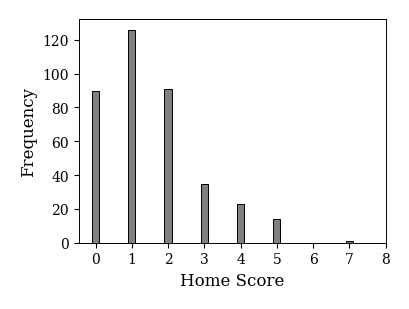

In [63]:
home_score = df_game.loc[df_game['league']=='England', 'home_score']

fig, ax = plt.subplots(figsize=(4,3))
x = np.arange(home_score.max()+2)
ax.hist(home_score, 
        bins=x, # 階級の左端の値を指定する
        align='left',    # バーの中央を階級の左端に合わせる
        histtype='bar',  # ヒストグラムのスタイル
        color='gray',    # バーの色
        edgecolor='k',   # バーの枠線の色
        rwidth=0.2       # バーの幅
        )

ax.set_xlabel('Home Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_xticks(x);

次に，上のヒストグラムがポアソン分布に従っているか調べるため，試合データから求めた平均値をパラメータとするポアソン分布を描いてみる．
イングランド・プレミアリーグのホームチームの平均得点は1.53であったので，

$$
    f(x) = \frac{1.53^{x}}{x!} \mathrm{e}^{-1.53}
$$

のグラフを描けば良い．

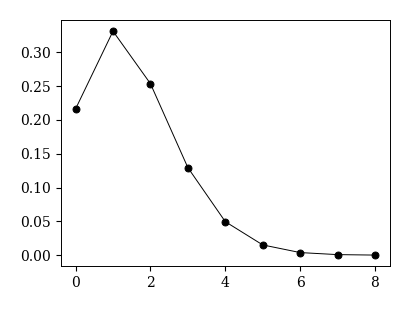

In [64]:
from scipy.stats import poisson

fig, ax = plt.subplots(figsize=(4, 3))
x = np.arange(home_score.max()+2)
fx = poisson.pmf(x, home_score.mean())
ax.plot(x, fx, '-ok')

上のグラフを見比べると，確かに似た分布になっていることが分かる．
そこで，最後に２つのグラフを合わせよう．

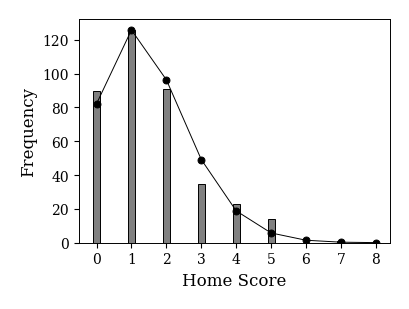

In [ ]:
from scipy.stats import poisson
home_score = df_game.loc[df_game['league']=='England', 'home_score']

fig, ax = plt.subplots(figsize=(4, 3))
x = np.arange(home_score.max()+2)
ax.hist(home_score, 
        bins=x, # 階級の左端の値を指定する
        align='left',    # バーの中央を階級の左端に合わせる
        histtype='bar',  # ヒストグラムのスタイル
        color='gray',    # バーの色
        edgecolor='k',   # バーの枠線の色
        rwidth=0.2
        )

fx = home_score.size * poisson.pmf(x, home_score.mean())
ax.plot(x, fx, '-ok')

ax.set_xlabel('Home Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_xticks(x);

実データ（棒グラフ）とポアソン分布（折れ線）の概形はおおよそ一致していることが分かる．
これは，得点の平均値と分散が近い値になったことと共に，サッカーの得点分布がポアソン分布に従うことを裏付ける材料となる．
もちろん，サッカーの得点分布が普遍的にポアソン分布に従うかどうかは，他のリーグのデータを調べなければわからない（確かめてみよ）．
また，$\chi^2$検定などを用いてより定量的な検証を行うことも必要である（試してみよ）．

### 演習問題

イングランドリーグのアウェイチームについても得点分布を描画し，実データから求めた平均値をパラメータとするポアソン分布を同じグラフに描画せよ．

In [128]:
# 解答欄


他のリーグについても同様に得点分布を描画し，実データから求めた平均値をパラメータとするポアソン分布を同じグラフに描画せよ．

In [ ]:
# 解答欄


## イベントデータの解析

Pappalardo-Wyscoutデータセットのイベントデータには，以下のようなデータが含まれている：
- （主にボールに関わる）イベントが起きた時刻
- イベント名
- イベントが始まった場所と終わった場所の座標
- イベントに付与されたフラグ
- 1試合あたり1500~2000イベント

イベントデータにはボールに関わる全てのプレー情報が含まれているため，これを分析すれば詳細な試合展開を把握することができる．
イベントデータは選手プロフィールや得点データに比べて格段に情報量が多いため，その扱いの難易度も高い．
基本的にExcelで解析するのは困難であり，Pandasの本領が最も発揮されるデータといえる．

#### 加工済みデータの内容

加工済みデータのダウンロード用リンクを以下にまとめる．<br>
※ W杯とCLのデータはヨーロッパリーグと試合数が異なるので除外する．

| リーグ | ファイル | ファイルサイズ |
| ---- | ---- | ---- |
| イングランド | [event_England.csv](https://tnarizuka.github.io/sports_data_programming/chap_6/event_England.csv) | 56.1MB |
| フランス | [event_France.csv](https://tnarizuka.github.io/sports_data_programming/chap_6/event_France.csv) | 56.6MB |
| ドイツ | [event_Germany.csv](https://tnarizuka.github.io/sports_data_programming/chap_6/event_Germany.csv) | 45.6MB |
| イタリア | [event_Italy.csv](https://tnarizuka.github.io/sports_data_programming/chap_6/event_Italy.csv) | 56.7MB |
| スペイン | [event_Spain.csv](https://tnarizuka.github.io/sports_data_programming/chap_6/event_Spain.csv) | 54.2MB |

以下では，イングランド・プレミアリーグのデータを解析対象とする．
準備として，次のファイルをダウンロードしてカレントディレクトリに移動する：
- イベントデータ：[event_England.csv](https://tnarizuka.github.io/sports_data_programming/chap_6/event_England.csv)
- 選手プロフィール：[player.csv](https://tnarizuka.github.io/sports_data_programming/chap_6/player.csv)

これらを以下のように読み込んでおく．

In [47]:
# イベントデータと選手プロフィールの読み込み
df_event = pd.read_csv('./event_England.csv')
df_player = pd.read_csv('./player.csv', header=0)

### イベントデータの詳細

In [48]:
df_event.head()

,id,game_id,half,t,team_id,player_id,event,subevent,x1,y1,x2,y2,goal,own_goal,assist,keypass,accurate
0,177959171,2499719,1,2.76,1609,25413,pass,simple_pass,51.4,33.3,32.6,53.0,0.0,0.0,0.0,0.0,1.0
1,177959172,2499719,1,4.95,1609,370224,pass,high_pass,32.6,53.0,53.6,51.0,0.0,0.0,0.0,0.0,1.0
2,177959173,2499719,1,6.54,1609,3319,pass,head_pass,53.6,51.0,36.8,48.3,0.0,0.0,0.0,0.0,1.0
3,177959174,2499719,1,8.14,1609,120339,pass,head_pass,36.8,48.3,43.1,64.6,0.0,0.0,0.0,0.0,1.0
4,177959175,2499719,1,10.30,1609,167145,pass,simple_pass,43.1,64.6,75.6,59.8,0.0,0.0,0.0,0.0,1.0


`df_event`には380試合分のイベントログが含まれており，その行数は64万行にのぼる．
`df_event`の各行は試合中の１イベントに対応し，各列にそのイベントに関する基本情報が収められている．
各列の内容は下表の通りである．

なお，`goal`，`assist`などのフラグは真ならば1，偽ならば0となっている（このようにカテゴリーデータを0,1で表現する手法をOne-Hotエンコーディングと呼ぶ）．
例えば，`goal`列が1である行では，そのイベントにおいて得点が入ったことを意味する．

| 変数名 | 内容 |
| ---- | ---- |
| id | イベント識別ID | 
| game_id | 試合ID |
| half | 1（前半），2（後半）|
| t | ハーフ開始からの経過時間（単位は秒） |
| team_id | チームID |
| player_id | 選手ID |
| event | イベント名 |
| event_id | イベントID |
| subevent | サブイベント名 |
| subevent_id | サブイベントID |
| x1 | イベント開始 $x$ 座標（単位はm） |
| y1 | イベント開始 $y$ 座標（単位はm） |
| x2 | イベント終了 $x$ 座標（単位はm） |
| y2 | イベント終了 $y$ 座標（単位はm） |
| goal | 得点フラグ（1/0） |
| own_goal | オウンゴールフラグ（1/0） |
| assist | アシストフラグ（1/0） |
| keypass | キーパスフラグ（1/0） |
| accurate | イベントの成否フラグ（1/0） |

**座標系**

イベント開始座標 $(x_{1}, y_{1})$ と終了座標 $(x_{2}, y_{2})$ は以下の座標系に従う：
- 原点は左下
- $x,\ y$ 座標の値はフィールドの横幅と縦幅の最大値に対する割合（単位はm）
  - $0\le x \le 105$
  - $0\le y \le 68$
- 両チームの攻撃方向は右方向となるように統一されている
  - チームや前後半に関係なく，$ x > 52.5 $ が相手陣，$ x < 52.5 $ が自陣
  - **※ 解析内容に応じて，攻撃方向が逆になるように変換する必要がある**

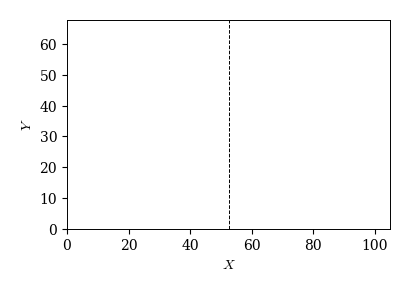

In [49]:
'''サッカーコートの描画'''
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_aspect('equal')  # アスペクト比を設定する

# ハーフウェイライン
ax.plot([52.5, 52.5], [0, 68], 'k--') 

# 描画範囲と軸ラベル
ax.set_xlim(0, 105); ax.set_ylim(0, 68)
ax.set_xlabel('$X$'); ax.set_ylabel('$Y$');

### イベントデータ解析の基本

イベントデータには，ボールの受け渡し時のイベント情報が含まれている．
イベントデータ解析の目的はこれらのデータから意味のある情報を抽出することである．
イベントデータを解析する際の手順は以下のようにまとめられる：
1. イベントデータから必要な行を条件付き抽出する
2. 条件付き抽出したデータを集計する
3. 集計したデータを可視化する

以下では，条件付き抽出の例をいくつか示す．

**特定の試合・時間帯の抽出**

`df_event`にはイングランド・プレミアリーグの全試合のイベントデータが含まれているため，まずは特定の試合のデータのみ抽出して`df_event_game`に保存する．

In [50]:
# 特定の試合を抽出する
game_id = df_event['game_id'].iloc[0]  # 最初の試合IDを取得
df_event_game = df_event.loc[df_event['game_id']==game_id].copy()

次に，`df_event_game`から特定の時間帯のデータを抽出する．
`half`列（前半が1，後半が2）や`t`列（ハーフ開始からの経過時間）を用いて条件付き抽出を行う．

In [51]:
# 前半のみ抽出する
df_event_game.loc[df_event_game['half']==1].tail()

,id,game_id,half,t,team_id,player_id,event,subevent,x1,y1,x2,y2,goal,own_goal,assist,keypass,accurate
896,177960132,2499719,1,2814.01,1631,8653,others_on_the_ball,touch,14.7,33.3,11.6,41.5,0.0,0.0,0.0,0.0,0.0
897,177960129,2499719,1,2814.48,1609,14869,pass,simple_pass,93.4,26.5,96.6,34.0,0.0,0.0,1.0,0.0,1.0
898,177960130,2499719,1,2815.90,1609,7945,shot,shot,96.6,34.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
899,177960121,2499719,1,2817.60,1631,8480,save_attempt,reflexes,105.0,68.0,8.4,34.0,1.0,0.0,0.0,0.0,0.0
900,177960127,2499719,1,2852.56,1631,14853,pass,simple_pass,32.6,16.3,105.0,68.0,0.0,0.0,0.0,0.0,0.0


In [52]:
# 前半開始20秒までを抽出する
df_event_game.loc[(df_event_game['half']==1) & (df_event_game['t']<20)].tail()

,id,game_id,half,t,team_id,player_id,event,subevent,x1,y1,x2,y2,goal,own_goal,assist,keypass,accurate
6,177959186,2499719,1,13.96,1631,8653,pass,head_pass,24.2,17.0,41.0,10.2,0.0,0.0,0.0,0.0,1.0
7,177959189,2499719,1,14.77,1631,8013,duel,air_duel,41.0,10.2,34.6,13.6,0.0,0.0,0.0,0.0,0.0
8,177961218,2499719,1,14.77,1609,0,duel,air_duel,64.0,57.8,70.4,54.4,0.0,0.0,0.0,0.0,1.0
9,177959178,2499719,1,15.32,1609,167145,pass,head_pass,70.4,54.4,62.0,41.5,0.0,0.0,0.0,0.0,1.0
10,177959179,2499719,1,18.05,1609,49876,pass,head_pass,62.0,41.5,47.2,30.6,0.0,0.0,0.0,0.0,1.0


**特定のイベントの抽出**

イベントデータには，`'event'`列と`'subevent'`列が存在する．
`'event'`列は`'pass'`，`'foul'`などの大分類，`'subevent'`列は`'simple_pass'`や`'high_pass'`などの小分類となっている．
`'event'`および`'subevent'`のリストは[event_list.csv](https://tnarizuka.github.io/sports_data_programming/chap_6/event_list.csv) にまとめられている．

In [53]:
# event列が'pass'の行を抽出
df_event_game.loc[df_event_game['event']=='pass'].head()

,id,game_id,half,t,team_id,player_id,event,subevent,x1,y1,x2,y2,goal,own_goal,assist,keypass,accurate
0,177959171,2499719,1,2.76,1609,25413,pass,simple_pass,51.4,33.3,32.6,53.0,0.0,0.0,0.0,0.0,1.0
1,177959172,2499719,1,4.95,1609,370224,pass,high_pass,32.6,53.0,53.6,51.0,0.0,0.0,0.0,0.0,1.0
2,177959173,2499719,1,6.54,1609,3319,pass,head_pass,53.6,51.0,36.8,48.3,0.0,0.0,0.0,0.0,1.0
3,177959174,2499719,1,8.14,1609,120339,pass,head_pass,36.8,48.3,43.1,64.6,0.0,0.0,0.0,0.0,1.0
4,177959175,2499719,1,10.30,1609,167145,pass,simple_pass,43.1,64.6,75.6,59.8,0.0,0.0,0.0,0.0,1.0


In [54]:
# subevent列が'simple_pass'の行を抽出
df_event_game.loc[df_event_game['subevent']=='simple_pass'].head()

,id,game_id,half,t,team_id,player_id,event,subevent,x1,y1,x2,y2,goal,own_goal,assist,keypass,accurate
0,177959171,2499719,1,2.76,1609,25413,pass,simple_pass,51.4,33.3,32.6,53.0,0.0,0.0,0.0,0.0,1.0
4,177959175,2499719,1,10.30,1609,167145,pass,simple_pass,43.1,64.6,75.6,59.8,0.0,0.0,0.0,0.0,1.0
5,177959177,2499719,1,12.55,1609,3319,pass,simple_pass,75.6,59.8,80.9,51.0,0.0,0.0,0.0,0.0,0.0
17,177959196,2499719,1,29.98,1631,265366,pass,simple_pass,30.4,17.7,38.8,5.4,0.0,0.0,0.0,0.0,1.0
18,177959197,2499719,1,31.16,1631,8013,pass,simple_pass,38.8,5.4,24.2,3.4,0.0,0.0,0.0,0.0,1.0


In [55]:
# event列が'shot'の行を抽出
df_event_game.loc[(df_event_game['goal']==1)].head()

,id,game_id,half,t,team_id,player_id,event,subevent,x1,y1,x2,y2,goal,own_goal,assist,keypass,accurate
46,177959212,2499719,1,94.60,1609,25413,shot,shot,92.4,27.9,0.0,0.0,1.0,0.0,0.0,0.0,1.0
47,177959226,2499719,1,96.97,1631,8480,save_attempt,reflexes,105.0,68.0,12.6,40.1,1.0,0.0,0.0,0.0,0.0
91,177959280,2499719,1,254.75,1631,14763,shot,shot,100.8,35.4,105.0,68.0,1.0,0.0,0.0,0.0,1.0
92,177959249,2499719,1,256.55,1609,7882,save_attempt,reflexes,0.0,0.0,4.2,32.6,1.0,0.0,0.0,0.0,0.0
554,177959759,2499719,1,1710.86,1631,12829,shot,shot,98.7,36.7,105.0,68.0,1.0,0.0,0.0,0.0,1.0


In [56]:
# イベント名が'pass'で，'accurate'フラグが1である行（成功パス）を抽出
df_event_game.loc[(df_event_game['event']=='pass') & (df_event_game['accurate']==1)].head()

,id,game_id,half,t,team_id,player_id,event,subevent,x1,y1,x2,y2,goal,own_goal,assist,keypass,accurate
0,177959171,2499719,1,2.76,1609,25413,pass,simple_pass,51.4,33.3,32.6,53.0,0.0,0.0,0.0,0.0,1.0
1,177959172,2499719,1,4.95,1609,370224,pass,high_pass,32.6,53.0,53.6,51.0,0.0,0.0,0.0,0.0,1.0
2,177959173,2499719,1,6.54,1609,3319,pass,head_pass,53.6,51.0,36.8,48.3,0.0,0.0,0.0,0.0,1.0
3,177959174,2499719,1,8.14,1609,120339,pass,head_pass,36.8,48.3,43.1,64.6,0.0,0.0,0.0,0.0,1.0
4,177959175,2499719,1,10.30,1609,167145,pass,simple_pass,43.1,64.6,75.6,59.8,0.0,0.0,0.0,0.0,1.0


In [57]:
# イベント名が'shot'で，'goal'フラグが1である行（成功シュート）
df_event_game.loc[(df_event_game['event']=='shot') & (df_event_game['goal']==1)]

,id,game_id,half,t,team_id,player_id,event,subevent,x1,y1,x2,y2,goal,own_goal,assist,keypass,accurate
46,177959212,2499719,1,94.60,1609,25413,shot,shot,92.4,27.9,0.0,0.0,1.0,0.0,0.0,0.0,1.0
91,177959280,2499719,1,254.75,1631,14763,shot,shot,100.8,35.4,105.0,68.0,1.0,0.0,0.0,0.0,1.0
554,177959759,2499719,1,1710.86,1631,12829,shot,shot,98.7,36.7,105.0,68.0,1.0,0.0,0.0,0.0,1.0
898,177960130,2499719,1,2815.90,1609,7945,shot,shot,96.6,34.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1107,177960379,2499719,2,634.31,1631,12829,shot,shot,96.6,36.7,105.0,68.0,1.0,0.0,0.0,0.0,1.0
1570,177960849,2499719,2,2231.12,1609,7870,shot,shot,98.7,42.8,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1613,177960902,2499719,2,2374.62,1609,26010,shot,shot,95.6,29.9,0.0,0.0,1.0,0.0,0.0,0.0,1.0


### イベント別のヒートマップ

条件付き抽出の応用として，イベント別にヒートマップを描いてみよう．
まず，以下のようにヒートマップを描く`plot_event_hmap`関数を作成する．
この関数は，$x,\ y$座標のデータを引数として受け取り，matplotlibの`hist2d`関数を用いてヒートマップを描く．

In [102]:
def plot_event_hmap(x, y, cm='Greens'):
    '''
    イベントデータからヒートマップを描画する
    -- 引数 ---
    x: X座標のデータ
    y: Y座標のデータ
    cm: カラーマップの名前
    例: plot_event_hmap(df_event_game['x'], df_event_game['y'], cm='Blues')
    '''
    
    fig, ax = plt.subplots(figsize=(4, 4))
    
    # アスペクト比の変更
    ax.set_aspect('equal')
    
    # X座標とY座標に小さなランダムノイズを追加（ヒートマップに筋が入るのを防ぐ）
    x += np.random.uniform(-0.1, 0.1, size=len(x))
    y += np.random.uniform(-0.1, 0.1, size=len(y))
    
    # ヒートマップの描画
    ret = ax.hist2d(x, y, # データのX座標とY座標
                    bins=[50, 30], # X方向とY方向のビン数
                    range=[[0, 105], [0, 68]], # 描画範囲
                    cmap=cm, cmin=0)

    # カラーバーを追加
    fig.colorbar(ret[3], orientation='vertical', shrink=0.4, aspect=10, pad=0.05)
    
    # ハーフウェイラインを追加
    ax.plot([52.5, 52.5], [0, 68], 'k--')

    # 描画範囲とラベル
    ax.set_xlim(0, 105); ax.set_ylim(0, 68)
    ax.set_xlabel('$X$'); ax.set_ylabel('$Y$')

特定のイベントだけを条件付き抽出してその$x,\ y$座標を`plot_event_hmap`関数に渡せば，そのイベントが行われたフィールド上の位置をヒートマップで可視化することができる．
以下にいくつかの例を示す．

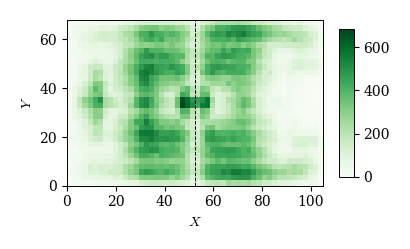

In [103]:
# パス
cond = (df_event['event']=='pass')
x, y = df_event.loc[cond, 'x1'], df_event.loc[cond, 'y1']
plot_event_hmap(x, y)

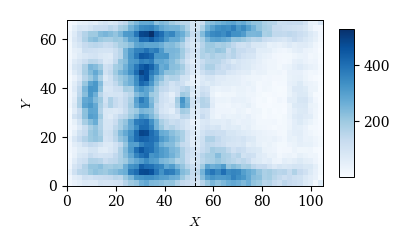

In [104]:
# ディフェンダー
player_id = df_player.loc[df_player['role']=='DF', 'player_id']
cond = df_event['player_id'].isin(player_id)
x, y = df_event.loc[cond, 'x1'], df_event.loc[cond, 'y1']
plot_event_hmap(x, y, cm='Blues')

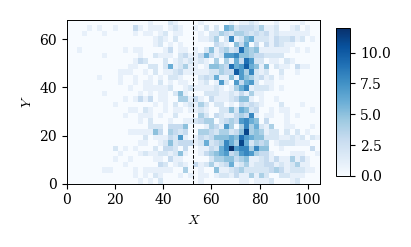

In [105]:
# 特定の選手（エジル）のパス
cond = (df_event['event']=='pass') & (df_event['player_id']==3319)
x, y = df_event.loc[cond, 'x1'], df_event.loc[cond, 'y1']
plot_event_hmap(x, y, 'Blues')

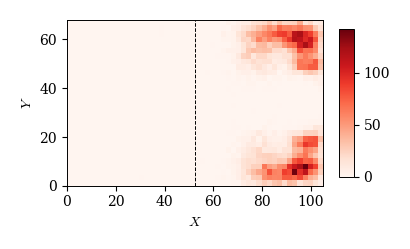

In [106]:
# クロス
cond = (df_event['subevent']=='cross')
x, y = df_event.loc[cond, 'x1'], df_event.loc[cond, 'y1']
plot_event_hmap(x, y, 'Reds')

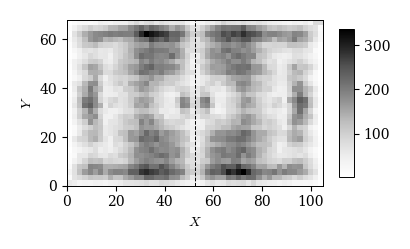

In [107]:
# デュエル
cond = (df_event['event']=='duel')
x, y = df_event.loc[cond, 'x1'], df_event.loc[cond, 'y1']
plot_event_hmap(x, y, 'Greys')

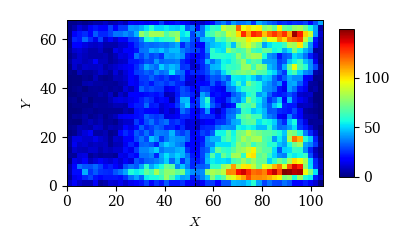

In [108]:
# デュエル（攻撃時）
cond = (df_event['subevent']=='ground_attacking_duel')
x, y = df_event.loc[cond, 'x1'], df_event.loc[cond, 'y1']
plot_event_hmap(x, y, 'jet')

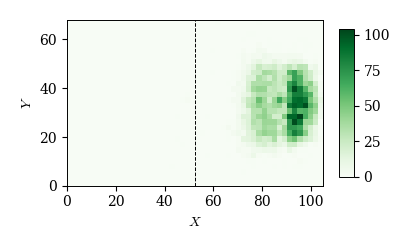

In [109]:
# シュート
cond = (df_event['event']=='shot')
x, y = df_event.loc[cond, 'x1'], df_event.loc[cond, 'y1']
plot_event_hmap(x, y)

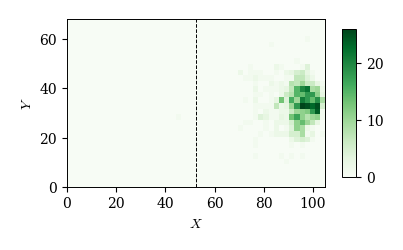

In [110]:
# シュート（成功）
cond = (df_event['event']=='shot') & (df_event['goal']==1)
x, y = df_event.loc[cond, 'x1'], df_event.loc[cond, 'y1']
plot_event_hmap(x, y)

### 選手のランキング

シーズンが終了すると，チームのリーグ成績と共に選手の個人成績が発表される．
個人成績は，シュート数やゴール数などの部門別ランキングとなっている．
ここでは，イベントデータを用いてこれらのランキングを求めてみよう．
なお，どのようなプレーをシュートやパスと見なすかは用いるデータセットによって異なっており，
以下で求めるランキングが公式発表されたものと完全に一致するわけではない．
2017年度プレミアリーグの個人成績は例えば，
- https://www.premierleague.com/stats

で確認できるが，細かい数値は本データセットから求めたものと一致しない．

ランキングの作成方法は以下の通りである．
- ランキング項目に応じて条件付き抽出する．
  - 例えば，パス数の場合は`event`列が`pass`である行を抽出する
- 条件付き抽出後のDataFrameに対し，`player_id`ごとの出現回数を求める
  - DataFrameの`value_counts`メソッドを用いる
- 選手プロフィール`df_player`を用いて`player_id`を選手名に変換する
  - `player_id`と`name`が対応した辞書を作成し，`rename`メソッドを用いる

In [35]:
# 'player_id'と'name'が対応した辞書の作成
dict_id_name = dict(df_player[['player_id', 'name']].values)

**シュート数**

In [36]:
cond = (df_event['subevent']=='shot') | (df_event['subevent']=='free_kick_shot') | (df_event['subevent']=='penalty')
df_shot_rank = df_event.loc[cond, 'player_id'].value_counts()
df_shot_rank = df_shot_rank.rename(index=dict_id_name)  # 選手IDを選手名に変換する
df_shot_rank.head(10)

player_id
H_Kane            175
Mohame_Salah      142
C_Eriksen          97
Richarlison        92
S_Agüero           91
K_D_Bruyne         91
A_Sánchez          85
R_Sterling         80
R_Lukaku           80
Robert_Firmino     80
Name: count, dtype: int64

**パス数**

In [37]:
df_pass_rank = df_event.loc[(df_event['event']=='pass'), 'player_id'].value_counts()
df_pass_rank = df_pass_rank.rename(index=dict_id_name)  # 選手IDを選手名に変換する
df_pass_rank.head(10)

player_id
G_Xhaka         2974
N_Otamendi      2964
Fernandinho     2842
Azpilicueta     2713
K_D_Bruyne      2672
N_Matić         2456
Davi_Silva      2382
J_Vertonghen    2370
K_Walker        2316
C_Eriksen       2196
Name: count, dtype: int64

**アシスト数**

In [38]:
df_assist_rank = df_event.loc[(df_event['assist']==1), 'player_id'].value_counts()
df_assist_rank = df_assist_rank.rename(index=dict_id_name)  # 選手IDを選手名に変換する
df_assist_rank.head(10)

player_id
K_D_Bruyne      16
L_Sané          13
R_Mahrez        10
R_Sterling      10
Davi_Silva      10
H_Mkhitaryan     9
D_Alli           9
C_Eriksen        9
Mohame_Salah     8
P_Groß           8
Name: count, dtype: int64

**ゴール数**

In [39]:
cond = ((df_event['event']=='shot') | (df_event['event']=='free_kick')) & (df_event['goal']==1)
df_goal_rank = df_event.loc[cond, 'player_id'].value_counts()
df_goal_rank = df_goal_rank.rename(index=dict_id_name)  # 選手IDを選手名に変換する
df_goal_rank.head(10)

player_id
Mohame_Salah      32
H_Kane            29
S_Agüero          21
J_Vardy           20
R_Sterling        18
R_Lukaku          16
Robert_Firmino    15
A_Lacazette       14
Gabrie_Jesus      13
G_Murray          12
Name: count, dtype: int64

### 演習問題

イベントデータの`half`列と`t`列を用いて様々な時間帯のデータを抽出せよ．

In [ ]:
# 解答欄


イベントデータの`event`列や`subevent`列，フラグ列を用いて様々な条件で場面を抽出し，`plot_evemt_hmap`関数を用いてヒートマップを描画せよ．

In [ ]:
# 解答欄


好きな選手を一人選び，その選手のイベントデータを抽出してヒートマップを描画せよ．
このヒートマップを基に選手のプレースタイルを考察せよ．

In [ ]:
# 解答欄


イングランド以外のリーグについて，選手のランキングを求めよ．
また，ウェブで公開されている実際の選手ランキングと比較せよ．

In [ ]:
# 解答欄


## 章末問題

**問題A：リーグ戦の勝ち点変動**

以下のデータをダウンロードしてカレントディレクトリに移動し，pandasのDataFrameに読み込め．
- 試合情報のデータ（[game.csv](https://tnarizuka.github.io/sports_data_programming/chap_6/game.csv)）
- チーム情報のデータ（[team.csv](https://tnarizuka.github.io/sports_data_programming/chap_6/team.csv)）

In [137]:
df_game = pd.read_csv('./game.csv', header=0)
df_team = pd.read_csv('./team.csv', header=0)

好きなリーグを一つ選び，`df_game`と`df_team`からそのリーグのデータだけを抽出せよ．

In [ ]:
# 解答欄


選んだリーグに所属するチームを一つ選び，全試合の得点・失点・得失点差・勝ち点・累積勝ち点を記録したDataFrameを作成せよ．

In [ ]:
# 解答欄


選んだチームについて，横軸に節，縦軸に累積勝ち点を取ったグラフを作成し，1シーズンの勝ち点の変動を可視化せよ．

In [ ]:
# 解答欄


全チームの累積勝ち点を同じグラフに描画し，チームごとの勝ち点の変動を比較せよ．

In [ ]:
# 解答欄


**問題B：アイスホッケーの得点分布**

[ice_hockey_score.csv](https://tnarizuka.github.io/sports_data_programming/chap_6/ice_hockey_score.csv)は，NHL(National Hockey League)の2000シーズン〜2019シーズンの全試合の得点データである．<br>
※ このデータは https://www.kaggle.com/datasets/martinellis/nhl-game-data/ から取得した．

このデータをpandasのDataFrameに読み込め．

In [ ]:
# 解答欄


シーズンごとにホームチームとアウェイチームの平均得点を求め，ホームとアウェイの違いとその要因を考察せよ．また，サッカーの平均得点と比較せよ．<br>
※ アイスホッケーにはルール上ホームアドバンテージがあることが知られている．

In [ ]:
# 解答欄


好きなシーズンを選び，アウェイチームとホームチームの得点分布を描画せよ．また，実データから求めた平均値をパラメータとするポアソン分布を同じグラフに描画せよ．

In [ ]:
# 解答欄


**問題C：シュート距離とシュート成功率の関係**

好きなリーグのイベントデータをダウンロードしてpandasのDataFrameに読み込め．

In [ ]:
# 解答欄
df_event = 

`df_event`から以下の条件でシュートイベントだけを抽出し，新たに`df_shot`というDataFrameに保存せよ．<br>

In [ ]:
# 解答欄
df_shot = df_event.loc[(df_event['event']=='shot') | (df_event['event']=='free_kick'), ['x1', 'y1', 'goal']]

`df_shot`に新たに`success`列を追加し，0で初期化せよ．次に，成功したシュートに対して`success`列を1に更新せよ．
- `goal`列が1の行が成功したシュートである．

In [ ]:
# 解答欄


`df_shot`に新たに`distance`列を追加し，シュート距離（シュートの開始座標から相手ゴールの中心までの距離）を計算して保存せよ．
- 相手ゴールの中心の座標は $(105, 34)$ である．

In [ ]:
# 解答欄


以下のコードを実行し，`df_shot['distance']`の値を5m刻みの値に丸めよ．

In [ ]:
# 解答欄
df_shot['distance'] = np.round(df_shot['distance']/5, 0) * 5

以下のコードを実行し，シュート距離の値ごとにシュート成功率を計算せよ．<br>
- `groupby`メソッドを用いて`df_shot`を`distance`列の値でグループ化する
- グループごとに`'success'`の平均値を計算してシュート成功率を求める

In [ ]:
# 解答欄
distance = df_shot.groupby('distance')['success'].mean().index  # シュート距離
success_rate = df_shot.groupby('distance')['success'].mean().values  # シュート成功率

シュート距離とシュート成功率の関係を散布図で可視化せよ．
- この散布図を用いると，シュート位置のデータ（座標）が与えられたときに，シュート成功率を予測することができる．
- このような予測モデルを得点期待値モデル（Expected Goals Model, xGモデル）と呼ぶ．

In [ ]:
# 解答欄
